<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula05b%20-%20%C3%A1rvore%20de%20decis%C3%A3o%20-%20atributos%20cont%C3%ADnuos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [199]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:,2:]
y = iris.target

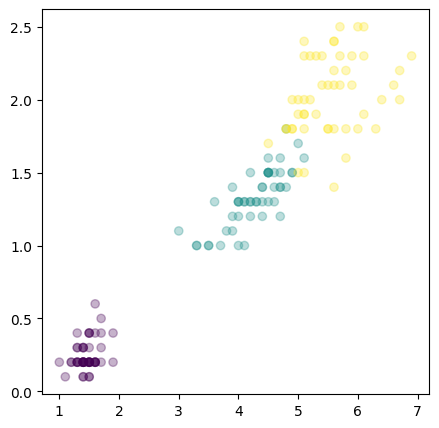

In [200]:
import matplotlib.pyplot as plt

def plotDataset(X, y):
  plt.figure(figsize=(5, 5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.3)

plotDataset(X, y)
plt.show()

In [201]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def most_common(y):
  return max(set(y), key=lambda label: sum(y==label))

class ZeroR(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.answer = most_common(y)
  def predict(self, X):
    return [self.answer]*X.shape[0]

model = ZeroR()
model.fit(X, y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))

0.3333333333333333


In [236]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    # stratify=y, random_state=42,
                                                    shuffle=True)
model = ZeroR()
model.fit(X_train, y_train)
yhat = model.predict(X_test)
accuracy = accuracy_score(y_test, yhat)
print('Accuracy: %.3f' % (accuracy*100))

Accuracy: 26.667


In [264]:
import numpy as np

# características e valores aleatórios
class DecisionTree(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.feature = np.random.randint(X.shape[1])
        self.value = np.random.choice(list(set(X[:, self.feature])))
        greaters = X[:, self.feature] >= self.value
        if sum(greaters) > 0 and sum(~greaters) > 0:
            self.greaters_tree = DecisionTree().fit(X[greaters], y[greaters])
            self.lessers_tree = DecisionTree().fit(X[~greaters], y[~greaters])
        else:
            self.answer = most_common(y)
        return self

    def predict(self, X):
        if hasattr(self, 'answer'):
            return [self.answer]*X.shape[0]
        else:
            greaters = X[:, self.feature] >= self.value
            return np.where(greaters, self.greaters_tree.predict(X), self.lessers_tree.predict(X))

model = DecisionTree()
model.fit(X, y)
ypred = model.predict(X)
print(accuracy_score(y, ypred))

0.86


In [277]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    # stratify=y, random_state=42,
                                                    shuffle=True)
model = DecisionTree()
model.fit(X_train, y_train)
yhat = model.predict(X_test)
accuracy = accuracy_score(y_test, yhat)
print('Accuracy: %.3f' % (accuracy*100))

Accuracy: 93.333


In [278]:
def defineAxes(X):
  off_set = 0.1
  x_min, x_max = X[:, 0].min() - off_set, X[:, 0].max()
  y_min, y_max = X[:, 1].min() - off_set, X[:, 1].max()
  return x_min, x_max, y_min, y_max

def plotPredictions(model, X, y):
  x_min, x_max, y_min, y_max = defineAxes(X)
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)

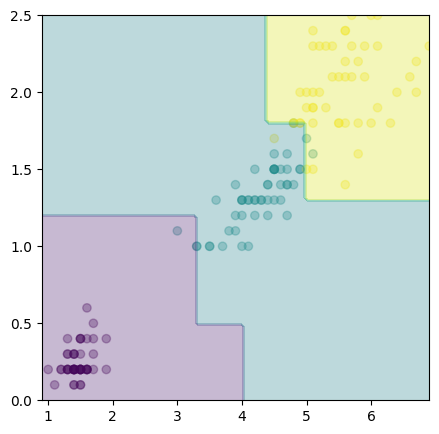

In [285]:
model = DecisionTree()
model.fit(X, y)
plotDataset(X, y)
plotPredictions(model, X, y)
plt.show()

In [287]:
def gini(y):
  labels = list(set(y))
  x = 0
  for label in labels:
    label_prob = np.mean(y==label)
    x += label_prob**2
  return 1-x

print(gini(y))

0.6666666666666667


In [289]:
def impurity_value(x, y, value, impurity_function):
  greaters = x >= value
  greaters_impurity = impurity_function(y[greaters])
  lessers_impurity = impurity_function(y[~greaters])
  return (np.mean(greaters)) * greaters_impurity + (np.mean(~greaters)) * lessers_impurity

print(impurity_value(X[:,0], y, 2.5, gini))

0.3333333333333333


In [297]:
def best_split(x, y, impurity_function):
  best_value = 0
  best_value_impurity = float('inf')
  x = np.sort(x)
  for i in range(1, len(x)):
    value = (x[i-1]+x[i])/2
    value_impurity = impurity_value(x, y, value, impurity_function)
    if value_impurity < best_value_impurity:
      best_value = value
      best_value_impurity = value_impurity
  return best_value, best_value_impurity

print(best_split(X[:,1], y, gini))

(np.float64(0.8), np.float64(0.3333333333333333))


In [295]:
def best_feature(X, y, impurity_function):
  best_feature = 0
  best_value = 0
  best_value_impurity = float('inf')
  for feature in range(X.shape[1]):
    value, _ = best_split(X[:,feature], y, impurity_function)
    feature_impurity = impurity_value(X[:,feature], y, value, impurity_function)
    if feature_impurity < best_value_impurity:
      best_feature = feature
      best_value_impurity = feature_impurity
      best_value = value
  return best_feature, best_value, best_value_impurity

print(best_feature(X, y, gini))

(0, np.float64(2.45), np.float64(0.3333333333333333))


In [302]:
class DecisionTree(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.feature, self.value, self.impurity = best_feature(X, y, gini)
        greaters = X[:, self.feature] >= self.value
        if sum(greaters) > 0 and sum(~greaters) > 0:
            self.greaters_tree = DecisionTree().fit(X[greaters], y[greaters])
            self.lessers_tree = DecisionTree().fit(X[~greaters], y[~greaters])
        else:
            self.answer = most_common(y)
        return self

    def predict(self, X):
        if hasattr(self, 'answer'):
            return [self.answer]*X.shape[0]
        else:
            greaters = X[:, self.feature] >= self.value
            return np.where(greaters, self.greaters_tree.predict(X), self.lessers_tree.predict(X))

model = DecisionTree()
model.fit(X, y)
ypred = model.predict(X)
print(accuracy_score(y, ypred))

0.9933333333333333


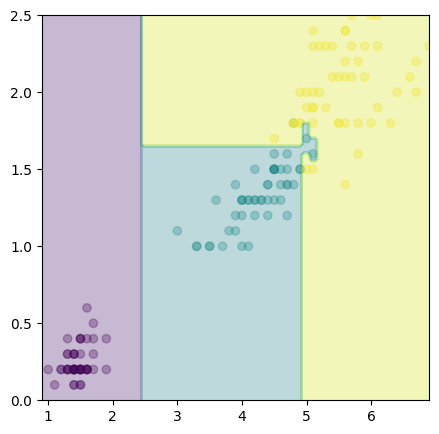

In [304]:
model = DecisionTree()
model.fit(X, y)
plotDataset(X, y)
plotPredictions(model, X, y)
plt.show()

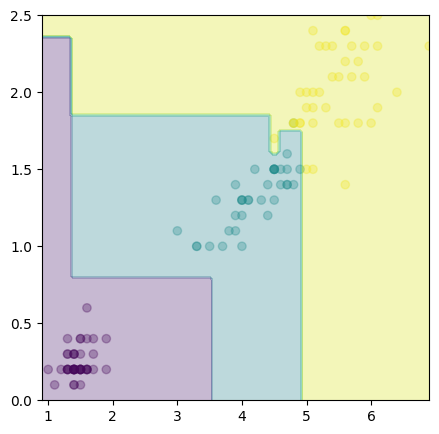

0.9


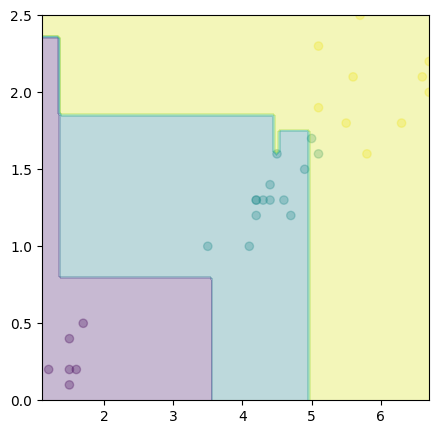

In [305]:
model = DecisionTree()
model.fit(X_train, y_train)
plotDataset(X_train, y_train)
plotPredictions(model, X_train, y_train)
plt.show()
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotPredictions(model, X_test, y_test)
plt.show()

In [306]:
from sklearn.model_selection import cross_val_score, KFold

scores = cross_val_score(DecisionTree(), X, y, cv=KFold(n_splits=5, shuffle=True))
print(scores)
print(np.mean(scores))

[1.         0.93333333 0.96666667 0.96666667 0.93333333]
0.96


In [329]:
class DecisionTree(BaseEstimator, ClassifierMixin):
    def __init__(self, max_depth=9999999, min_sample_split=2):
        self.max_depth = max_depth
        self.min_sample_split = min_sample_split

    def fit(self, X, y):
        self.feature, self.value, self.impurity = best_feature(X, y, gini)
        greaters = X[:, self.feature] >= self.value
        if sum(greaters) > self.min_sample_split and \
           sum(~greaters) > self.min_sample_split and \
           self.max_depth>0:
            self.greaters_tree = DecisionTree(self.max_depth-1).fit(X[greaters], y[greaters])
            self.not_greaters_tree = DecisionTree(self.max_depth-1).fit(X[~greaters], y[~greaters])
        else:
            self.answer = most_common(y)
        return self

    def predict(self, X):
        if hasattr(self, 'answer'):
            return [self.answer]*X.shape[0]
        else:
            greaters = X[:, self.feature] >= self.value
            return np.where(greaters, self.greaters_tree.predict(X), self.not_greaters_tree.predict(X))

model = DecisionTree(20, 10)
scores = cross_val_score(model, X, y, cv=KFold(n_splits=5, shuffle=True))
print(scores)
print(np.mean(scores))

[0.86666667 0.9        0.96666667 1.         1.        ]
0.9466666666666667


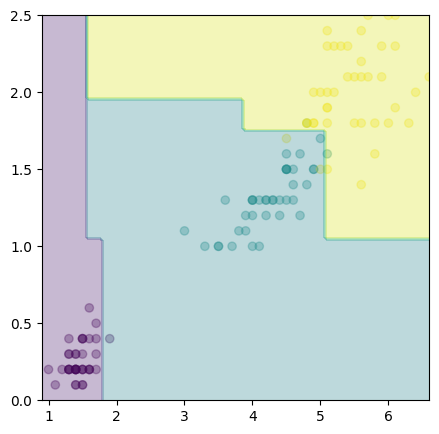

0.9666666666666667


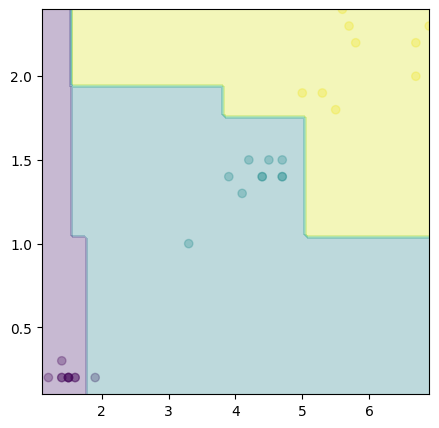

In [344]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    # stratify=y, random_state=42,
                                                    shuffle=True)
model = DecisionTree(100, 10)
model.fit(X_train, y_train)
plotDataset(X_train, y_train)
plotPredictions(model, X_train, y_train)
plt.show()
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotPredictions(model, X_test, y_test)
plt.show()

1.0


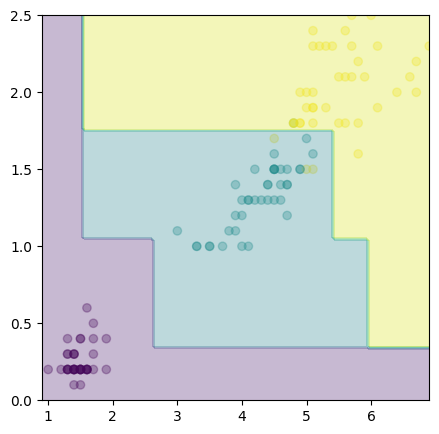

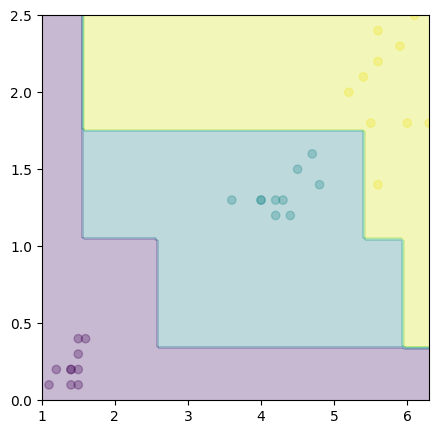

In [353]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, # random_state=42,
                                                    shuffle=True)
model = DecisionTree(100, 10)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))
plotDataset(X_train, y_train)
plotPredictions(model, X_train, y_train)
plt.show()
plotDataset(X_test, y_test)
plotPredictions(model, X_test, y_test)
plt.show()